<a href="https://colab.research.google.com/github/Samarth-27/Celebal-CEI/blob/main/week4_SamarthJain_Jecrc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10 Image Classification: ANN vs CNN

**Goal:** Build two classifiers on CIFAR-10 a plain ANN and a CNN  then compare how architecture choices, training tricks, and data augmentation affect accuracy.

CIFAR-10 has 60,000 colour images (32×32 pixels, 3 channels) split across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.


## 1. Imports

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0
TensorFlow: 2.20.0


## 2. Load CIFAR-10
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train:", x_train.shape, "  Test:", x_test.shape)
print("Label range:", y_train.min(), "–", y_train.max())

Train: (50000, 32, 32, 3)   Test: (10000, 32, 32, 3)
Label range: 0 – 9


## 3. Sample images

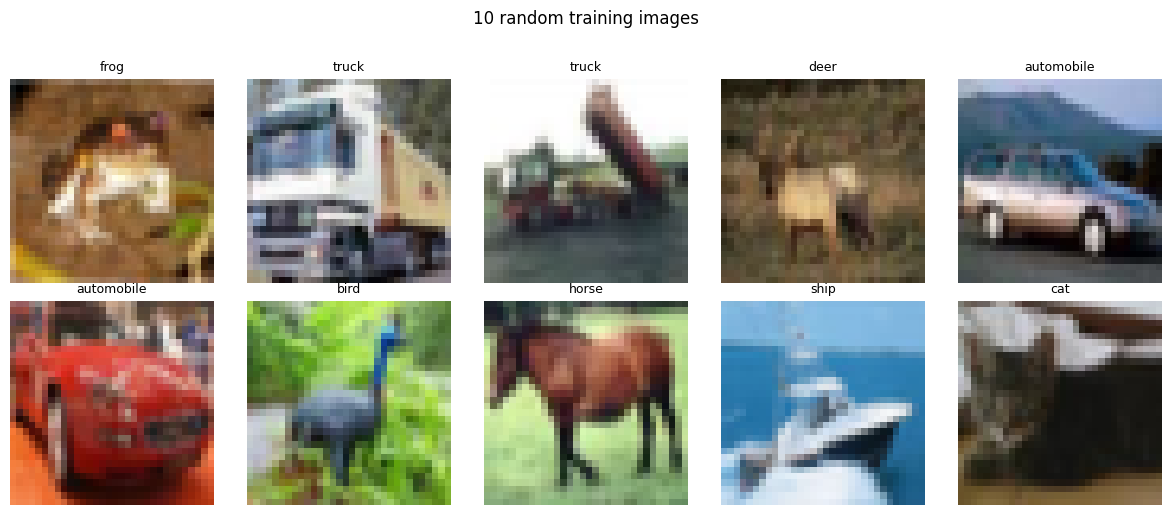

In [3]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i][0]], fontsize=9)
    plt.axis("off")
plt.suptitle("10 random training images", y=1.02)
plt.tight_layout()
plt.show()

## 4. Preprocessing

Pixel values are scaled to [0,1] by dividing by 255. For the ANN, each image is flattened into a 3072-length vector.

In [4]:
# Normalise
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flat versions for the ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm),  -1)

print("Normalised range:", x_train_norm.min(), "–", x_train_norm.max())
print("Flat shape:      ", x_train_flat.shape)

Normalised range: 0.0 – 1.0
Flat shape:       (50000, 3072)


## 5. Baseline ANN

The ANN uses Dense layers and treats each image as a flat vector, ignoring spatial relationships between pixels.

Task 1: Added a third hidden layer (128) to increase model capacity.
Task 2: Filter scaling applies to the CNN, not the ANN.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),   # extra layer — student task 1
    layers.Dense(10,  activation='softmax')
], name="ANN")

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

**task 3 & 4:** Training for 20 epochs with EarlyStopping (patience = 5). EarlyStopping watches validation loss; if it stops improving it halts training early and restores the best weights, so we never overfit without knowing it.

In [6]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2485 - loss: 2.0248 - val_accuracy: 0.3068 - val_loss: 1.8977
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.3047 - loss: 1.8926 - val_accuracy: 0.3354 - val_loss: 1.8548
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3226 - loss: 1.8417 - val_accuracy: 0.3586 - val_loss: 1.7749
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3371 - loss: 1.8092 - val_accuracy: 0.3700 - val_loss: 1.7772
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3490 - loss: 1.7824 - val_accuracy: 0.3902 - val_loss: 1.7297
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3562 - loss: 1.7682 - val_accuracy: 0.3802 - val_loss: 1.7472
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3649 - loss: 1.7459 - val_accuracy: 0.3852 - val_loss: 1.7172
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3621 - loss: 1.7460 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")

ANN Test Accuracy: 0.4416


**## 6. CNN**

The CNN learns local image features such as edges, corners, and textures using convolutional layers, making it more effective for image classification than an ANN.

* **Task 2:** Used the standard filter progression **32 → 64 → 128**, allowing deeper layers to learn more complex features.


In [8]:
cnn_model = models.Sequential([
    # Block 1 — 32 filters
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — 64 filters
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — 128 filters
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="CNN")

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

**Tasks 3 & 4**: Trained for 20 epochs with EarlyStopping to reduce overfitting.

In [9]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 201ms/step - accuracy: 0.4395 - loss: 1.5853 - val_accuracy: 0.5100 - val_loss: 1.3134
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.5897 - loss: 1.1603 - val_accuracy: 0.5782 - val_loss: 1.2324
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 203ms/step - accuracy: 0.6664 - loss: 0.9490 - val_accuracy: 0.6064 - val_loss: 1.1721
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 200ms/step - accuracy: 0.7133 - loss: 0.8170 - val_accuracy: 0.7072 - val_loss: 0.8705
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 202ms/step - accuracy: 0.7504 - loss: 0.7096 - val_accuracy: 0.6938 - val_loss: 0.8817
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 136s 193ms/step - accuracy: 0.7867 - loss: 0.6091 - val_accuracy: 0.7294 - val_loss: 0.8576
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 195ms/step - accuracy: 0.8125 - loss: 0.5306 - val_accuracy: 0.6404 - val_loss: 1.1221
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.8384 -

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")

CNN Test Accuracy: 0.7161


## 7. Augmented CNN

Task 5: Applied data augmentation (flip, rotate, zoom) to improve generalization and reduce overfitting.
Augmentation is used only during training and is disabled during testing.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augmentation")

aug_cnn_model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="Augmented_CNN")

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 153s 210ms/step - accuracy: 0.3619 - loss: 1.7770 - val_accuracy: 0.4324 - val_loss: 1.6111
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 149s 211ms/step - accuracy: 0.4665 - loss: 1.4803 - val_accuracy: 0.5114 - val_loss: 1.3802
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 150s 213ms/step - accuracy: 0.5240 - loss: 1.3376 - val_accuracy: 0.5494 - val_loss: 1.2836
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 215ms/step - accuracy: 0.5605 - loss: 1.2476 - val_accuracy: 0.5734 - val_loss: 1.2587
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 148s 210ms/step - accuracy: 0.5878 - loss: 1.1824 - val_accuracy: 0.5818 - val_loss: 1.2568
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


In [12]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}")

Augmented CNN Test Accuracy: 0.4232


**8. Learning Curves**

Learning curves compare training and validation performance across models. A large gap between the two indicates overfitting, while the augmented CNN is expected to show the smallest gap and best generalization.


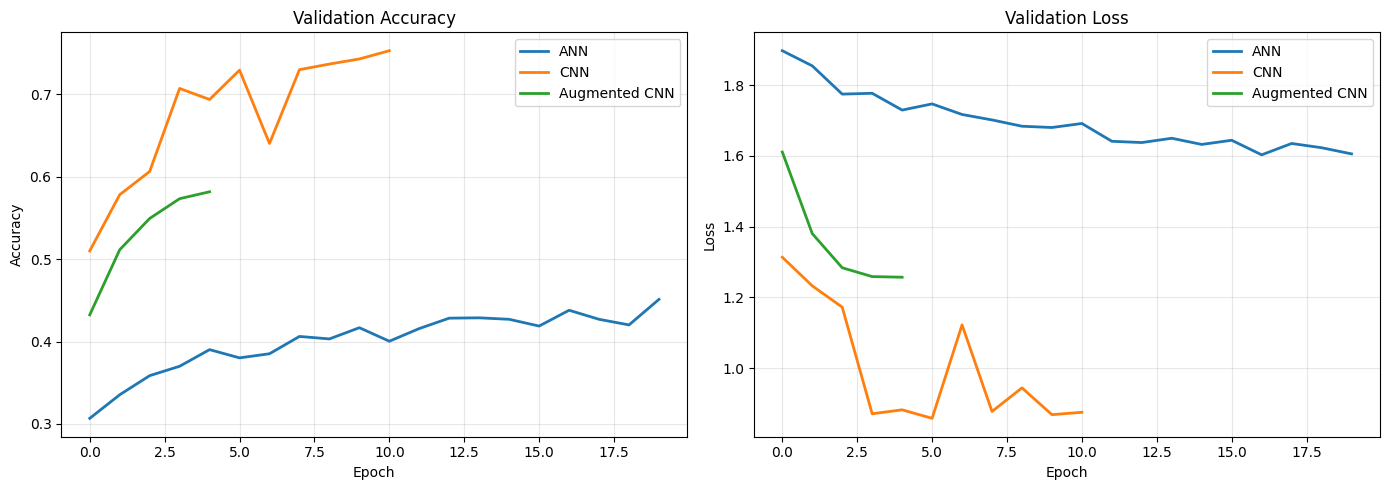

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation accuracy
axes[0].plot(ann_history.history['val_accuracy'],     label='ANN',           linewidth=2)
axes[0].plot(cnn_history.history['val_accuracy'],     label='CNN',           linewidth=2)
axes[0].plot(aug_history.history['val_accuracy'],     label='Augmented CNN', linewidth=2)
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation loss
axes[1].plot(ann_history.history['val_loss'],     label='ANN',           linewidth=2)
axes[1].plot(cnn_history.history['val_loss'],     label='CNN',           linewidth=2)
axes[1].plot(aug_history.history['val_loss'],     label='Augmented CNN', linewidth=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Train vs validation gap (overfitting check)

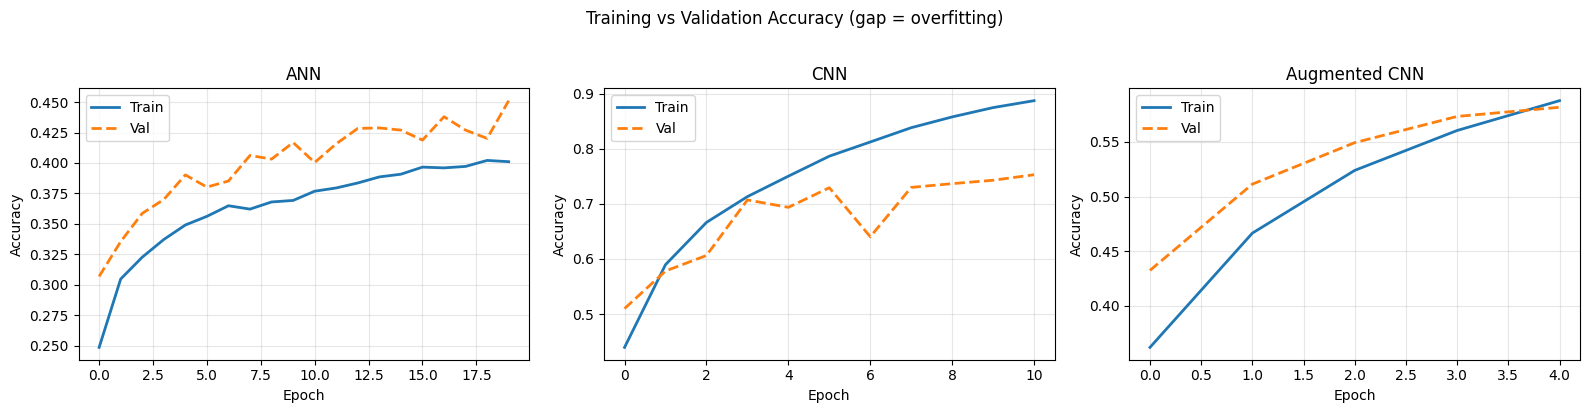

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pairs = [
    (ann_history, "ANN"),
    (cnn_history, "CNN"),
    (aug_history, "Augmented CNN"),
]

for ax, (hist, name) in zip(axes, pairs):
    ax.plot(hist.history['accuracy'],     label='Train', linewidth=2)
    ax.plot(hist.history['val_accuracy'], label='Val',   linewidth=2, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Training vs Validation Accuracy (gap = overfitting)", y=1.02)
plt.tight_layout()
plt.show()

## 9. Final comparison

In [15]:
comparison = pd.DataFrame({
    "Model":         ["ANN", "CNN", "Augmented CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc],
    "Test Loss":     [ann_test_loss, cnn_test_loss, aug_test_loss],
})
comparison["Test Accuracy %"] = (comparison["Test Accuracy"] * 100).round(2)
comparison = comparison.drop(columns="Test Accuracy")
comparison

,Model,Test Loss,Test Accuracy %
0,ANN,1.594124,44.16
1,CNN,0.921132,71.61
2,Augmented CNN,1.649581,42.32


## 10. Confusion matrix (best model)

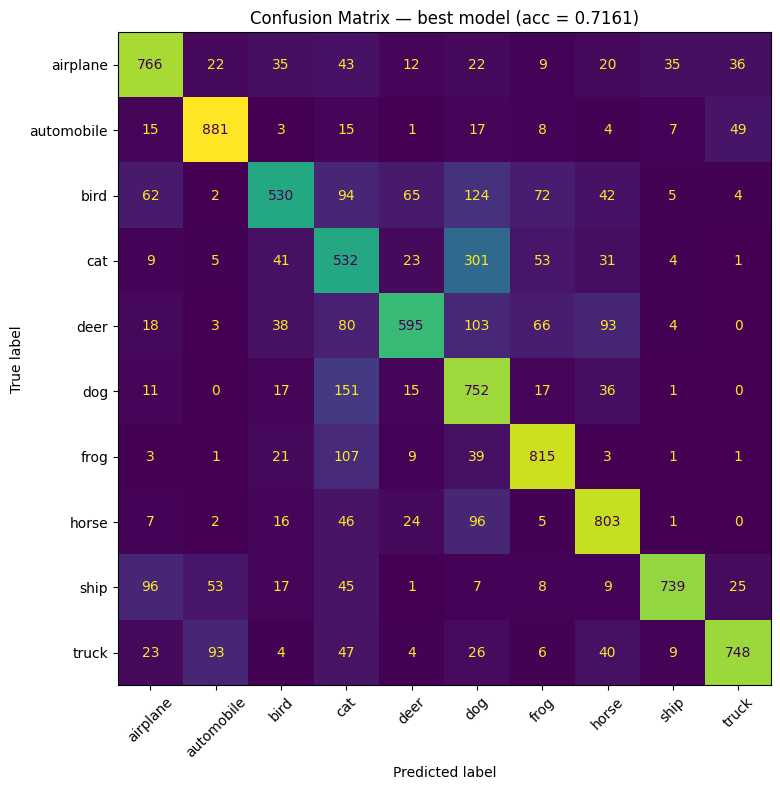

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pick whichever model scored highest on test set
best_acc   = max(ann_test_acc, cnn_test_acc, aug_test_acc)
best_model = {ann_test_acc: ann_model,
              cnn_test_acc: cnn_model,
              aug_test_acc: aug_cnn_model}[best_acc]
best_input = x_test_flat if best_model is ann_model else x_test_norm

preds = np.argmax(best_model.predict(best_input, verbose=0), axis=1)
cm    = confusion_matrix(y_test.flatten(), preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion Matrix — best model (acc = {best_acc:.4f})")
plt.tight_layout()
plt.show()

### **11. What I learned**

ANN's limitation: when you flatten a 32×32×3 image into a vector, all spatial context is gone. The model can pick up on individual pixel patterns but has no idea that a group of pixels forming a certain shape might mean "ear" or "wing."

**Why CNN works:** the filters slide across the image and catch the same feature wherever it appears. An edge on the left looks identical to an edge on the right. Pooling then compresses the output, and stacking blocks (32 → 64 → 128 filters) lets the model go from detecting edges to recognising actual object parts.

**BatchNormalization:** keeps activations from drifting between layers, which means faster training and less babysitting the learning rate.

**EarlyStopping:** instead of guessing how many epochs are "enough," it watches validation loss and stops when things stop improving then hands back the best weights. Genuinely useful.

**Data augmentation:** the model never sees the exact same image twice, so it can't just memorise. The train/val gap tightens up noticeably.
